# Lab 08：指定要畫哪個數字——Classifier-Free Guidance

對應講義：[第 08 課](../lessons/08_guidance.md)

1. 訓練一個條件 U-Net：10% 的時間把標籤換成「空標籤」（`drop_labels`）
2. 用 `ClassifierFreeGuidance` 包起來，掃 guidance scale $s$
3. 量化取捨：scale 越大，「畫得對不對」與「多不多樣」怎麼變

**執行時間**：CPU 上訓練約 15–20 分鐘。有 GPU 的話建議 `BASE_CHANNELS = 32`、`TRAIN_STEPS = 10000`、`EMA_DECAY = 0.999`。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


In [2]:
BASE_CHANNELS = 16
TRAIN_STEPS = 2000
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EMA_DECAY = 0.995
P_UNCOND = 0.1
NUM_CLASSES = 10
NULL_CLASS = NUM_CLASSES  # LabelEmbedding reserves index 10 for "no label"

## 1. 訓練條件模型

和 Lab 06 只差兩個地方：U-Net 多了 `num_classes`，損失函數收到的標籤先經過 `drop_labels`。

step 250/2000  loss 0.1131


step 500/2000  loss 0.0330


step 750/2000  loss 0.0298


step 1000/2000  loss 0.0278


step 1250/2000  loss 0.0268


step 1500/2000  loss 0.0261


step 1750/2000  loss 0.0256


step 2000/2000  loss 0.0252


trained 2000 steps in 14.1 min


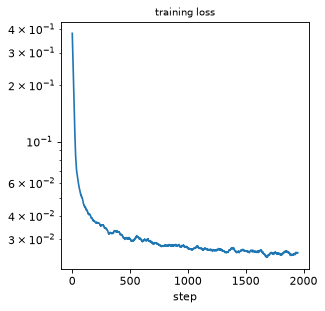

In [3]:
from diffusion_course.data import image_loader, infinite_batches
from diffusion_course.ddpm import ddpm_loss
from diffusion_course.guidance import drop_labels
from diffusion_course.models import UNet
from diffusion_course.schedules import NoiseSchedule
from diffusion_course.training import train
from diffusion_course.viz import new_axes, plot_loss

schedule = NoiseSchedule.create("linear", 1000).to(device)
model = UNet(in_channels=1, base_channels=BASE_CHANNELS, num_classes=NUM_CLASSES)


def cfg_loss(m: torch.nn.Module, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return ddpm_loss(m, schedule, x, drop_labels(y, P_UNCOND, NULL_CLASS))


result = train(
    model,
    cfg_loss,
    infinite_batches(image_loader("mnist", BATCH_SIZE)),
    num_steps=TRAIN_STEPS,
    lr=LEARNING_RATE,
    ema_decay=EMA_DECAY,
    device=device,
    log_every=250,
)
ema_model = result.sampling_model
print(f"trained {TRAIN_STEPS} steps in {result.seconds / 60:.1f} min")
(ax,) = new_axes(1, size=4)
plot_loss(result.losses, ax, window=50)
plt.show()

## 2. 掃 guidance scale

每一列是一個數字（0 到 9），每張圖用同一份起始雜訊，只改 scale。取樣用 DDIM 50 步（第 07 課）。
- $s = 0$：無條件（標籤被忽略）
- $s = 1$：普通條件模型
- $s > 1$：guidance

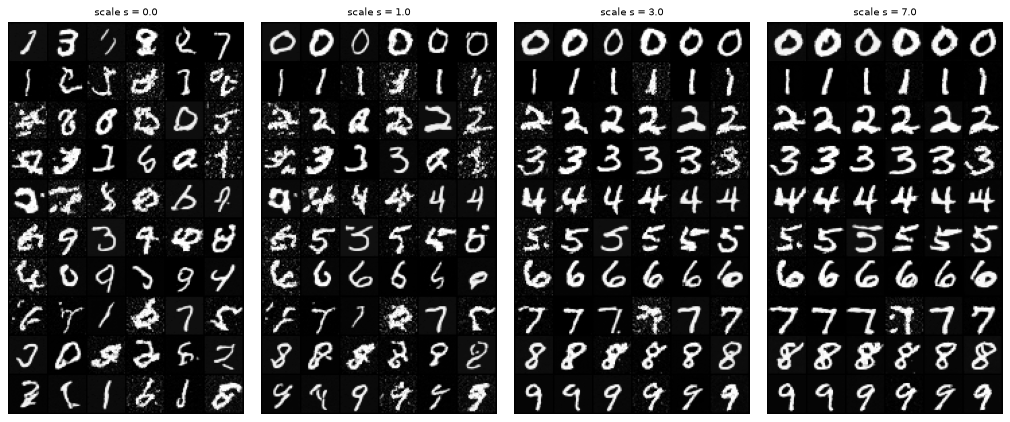

In [4]:
from diffusion_course.ddim import ddim_sample
from diffusion_course.guidance import ClassifierFreeGuidance
from diffusion_course.viz import show_images

PER_CLASS = 6
labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(PER_CLASS)
noise = torch.randn(len(labels), 1, 28, 28, device=device)

scales = [0.0, 1.0, 3.0, 7.0]
fig, axes = plt.subplots(1, len(scales), figsize=(3.2 * len(scales), 5.2))
for ax, scale in zip(axes, scales):
    guided = ClassifierFreeGuidance(ema_model, scale, NULL_CLASS)
    images = ddim_sample(guided, schedule, noise.shape, num_steps=50, y=labels, noise=noise, clip_x0=True)
    show_images(images, ax, nrow=PER_CLASS, title=f"scale s = {scale}")
plt.tight_layout()
plt.show()

## 3. 量化取捨

每個 scale 生成 500 張（每個數字 50 張），量三件事：

- **accuracy**：分類器認為的數字 = 要求的數字的比例（畫得對不對）
- **within-class diversity**：同一個數字的樣本之間的平均像素距離（多不多樣）
- **saturated pixels**：絕對值大於 0.95 的像素比例（過飽和的程度）

 scale  accuracy  confidence  diversity  saturated
   0.0     0.080       0.829      20.29      0.425
   1.0     0.876       0.937      18.32      0.424
   2.0     0.992       0.991      17.08      0.478
   3.0     0.996       0.997      16.49      0.520
   5.0     0.998       0.998      15.97      0.565
   8.0     0.998       0.998      15.69      0.571


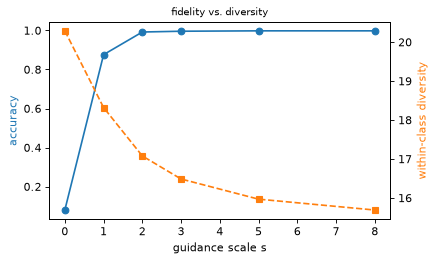

In [5]:
from diffusion_course.evaluation import get_digit_classifier, judge_samples

classifier = get_digit_classifier(device)
PER_CLASS_EVAL = 50
eval_labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(PER_CLASS_EVAL)
eval_noise = torch.randn(len(eval_labels), 1, 28, 28, device=device)


def within_class_diversity(images: torch.Tensor, labels: torch.Tensor) -> float:
    flat = images.flatten(1)
    distances = [torch.pdist(flat[labels == c]).mean() for c in range(NUM_CLASSES)]
    return torch.stack(distances).mean().item()


eval_scales = [0.0, 1.0, 2.0, 3.0, 5.0, 8.0]
table = []
for scale in eval_scales:
    guided = ClassifierFreeGuidance(ema_model, scale, NULL_CLASS)
    images = ddim_sample(guided, schedule, eval_noise.shape, num_steps=50, y=eval_labels, noise=eval_noise, clip_x0=True)
    judged = judge_samples(classifier, images, eval_labels)
    diversity = within_class_diversity(images, eval_labels)
    saturated = (images.abs() > 0.95).float().mean().item()
    table.append((scale, judged["accuracy"], judged["confidence"], diversity, saturated))

print(f"{'scale':>6}{'accuracy':>10}{'confidence':>12}{'diversity':>11}{'saturated':>11}")
for row in table:
    print(f"{row[0]:>6.1f}{row[1]:>10.3f}{row[2]:>12.3f}{row[3]:>11.2f}{row[4]:>11.3f}")

fig, ax1 = plt.subplots(figsize=(5.5, 3.2))
ax1.plot(eval_scales, [r[1] for r in table], "o-", color="tab:blue", label="accuracy")
ax1.set_xlabel("guidance scale s")
ax1.set_ylabel("accuracy", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(eval_scales, [r[3] for r in table], "s--", color="tab:orange", label="diversity")
ax2.set_ylabel("within-class diversity", color="tab:orange")
plt.title("fidelity vs. diversity", fontsize=9)
plt.show()

讀表：

- $s = 0$ 的 accuracy 只有 0.08，和亂猜（0.1）差不多——無條件模型隨便畫，只有約十分之一剛好是要求的數字。它的 confidence（0.83）也比 Lab 06 專門訓練的無條件模型（0.90）低：這個網路只有 10% 的訓練時間在學無條件分支。
- $s = 1$ 升到 0.876；$s = 2$ 就達到 0.99，之後趨於飽和。
- 同時，同一個數字的樣本越來越像（diversity 從 20.3 降到 15.7），過飽和的像素比例從 42% 增加到 57%。對照上面的圖：$s = 7$ 的每一列幾乎都是同一種寫法。

這就是講義 §1.3 的取捨。文生圖模型的 guidance scale 旋鈕，調的就是這條曲線上的位置。

## 4. 存檔

In [6]:
from diffusion_course.training import save_checkpoint
from diffusion_course.utils import CHECKPOINT_DIR

save_checkpoint(
    CHECKPOINT_DIR / "lab08_mnist_ddpm_unet_cond.pt",
    ema_model,
    arch="unet",
    model_kwargs={"in_channels": 1, "base_channels": BASE_CHANNELS, "num_classes": NUM_CLASSES},
    method="ddpm",
    schedule="linear",
    dataset="mnist",
    num_classes=NUM_CLASSES,
)

saved checkpoint to checkpoints/lab08_mnist_ddpm_unet_cond.pt


## 小結

- 條件模型 ＋ 訓練時隨機丟標籤 = 一個網路同時是條件與無條件模型。
- CFG 把兩者的差放大；scale 是「畫得像」與「多樣性」之間的旋鈕。
- `ClassifierFreeGuidance` 只是一層包裝，任何取樣器都能直接使用——下一課的 flow matching 也一樣。